<a href="https://colab.research.google.com/github/aydanali/ECON3916-Stats-and-ML/blob/main/FinalProject/3916_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [9]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** What sectors are causing the largest emissions and does more emission help economic growth?

**This is a prediction (umbrella) problem because:** Emissions are often seen as a necessiary biproduct of economic growth. Companies purchase carbon credits because it is cheaper to emit than to work to offset.
(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

**The decision this enables:** Countries, economists, and firms around the world would benefit from this data. They are able to see what sectors are causing the most direct impact on the climate and determine if the impact is worth the gain. Environmental scientists often say we are close to a point of no return, where we will not be able to stop the damange done, but with this we will be able to see what sectors are causing the most damange and which are worth public cost.
(Who is the stakeholder? What action would they take differently with your prediction?)

**Dataset:** Data on CO2 and Greenhouse Gas Emissions
- **Source:** Our World in Data (URL: https://github.com/owid/co2-data/tree/master)
- **N =** 50411
- **Features =** 'country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_per_capita', 'oil_co2', 'oil_co2_per_capita', 'other_co2_per_capita', 'other_industry_co2', 'primary_energy_consumption', 'share_global_cement_co2', 'share_global_co2', 'share_global_co2_including_luc', 'share_global_coal_co2', 'share_global_cumulative_cement_co2', 'share_global_cumulative_co2', 'share_global_cumulative_co2_including_luc', 'share_global_cumulative_coal_co2', 'share_global_cumulative_flaring_co2', 'share_global_cumulative_gas_co2', 'share_global_cumulative_luc_co2', 'share_global_cumulative_oil_co2', 'share_global_cumulative_other_co2', 'share_global_flaring_co2', 'share_global_gas_co2', 'share_global_luc_co2', 'share_global_oil_co2', 'share_global_other_co2', 'share_of_temperature_change_from_ghg', 'temperature_change_from_ch4', 'temperature_change_from_co2', 'temperature_change_from_ghg', 'temperature_change_from_n2o', 'total_ghg', 'total_ghg_excluding_lucf', 'trade_co2', 'trade_co2_share'

- **Target variable =** 'gdp'
- **Access date:** 4.19.2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [26]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

# df = pd.read_csv('your_data.csv')
# df = pd.read_csv('https://example.com/data.csv')

# Uncomment and modify one of the lines above
df = pd.read_csv('https://raw.githubusercontent.com/owid/co2-data/refs/heads/master/owid-co2-data.csv')

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df

Shape: (50411, 79)
Columns: ['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.000,0.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50406,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,0.496,0.032,8.491,-1.776,-17.298,...,NaN,0.106,0.001,0.001,0.002,0.0,24.146,14.463,1.991,23.450
50407,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,0.542,0.034,10.223,1.732,20.398,...,NaN,0.105,0.001,0.001,0.002,0.0,27.907,16.408,2.137,20.899
50408,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,0.387,0.024,12.232,2.009,19.653,...,NaN,0.104,0.001,0.001,0.002,0.0,29.917,18.830,1.380,11.283
50409,Zimbabwe,2023,ZWE,16340829.0,NaN,0.387,0.024,13.443,1.211,9.904,...,NaN,0.103,0.001,0.001,0.002,0.0,31.029,20.318,1.876,13.957


### 2.2 Basic Description

In [11]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,...,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017453e+07,3.300495e+11,7.890109,0.060013,420.227035,6.268847,42.598225,544.144592,7.483698,...,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308433e+08,3.086383e+12,62.988171,0.123562,1972.092032,62.199548,1721.913018,2273.281696,99.512520,...,17.448980,9.282343,0.015362,0.045687,0.062888,0.003048,2414.076755,1812.363570,259.018184,62.637598
min,1750.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,-1928.339000,-100.000000,-84.560000,-2298.978000,...,0.000000,-0.824000,-0.001000,0.000000,-0.001000,0.000000,-19.725000,0.000000,-2177.807000,-98.281000
25%,1875.000000,3.272140e+05,7.874038e+09,0.000000,0.000000,0.381000,-0.005000,-1.070500,6.667750,-0.727500,...,0.144000,0.003000,0.000000,0.000000,0.000000,0.000000,1.502000,0.221000,-2.262250,-6.828750
50%,1925.000000,2.291594e+06,2.743861e+10,0.000000,0.001000,5.081000,0.044000,3.813000,28.120000,0.112000,...,0.588500,0.081000,0.000000,0.000000,0.000000,0.000000,14.605500,2.222000,1.641000,8.381500
75%,1975.000000,9.986553e+06,1.212627e+11,0.524000,0.076250,53.656500,1.018000,10.884000,124.303250,2.765250,...,2.416500,0.373000,0.000000,0.001000,0.002000,0.000000,76.508500,27.863000,11.425500,32.782250
max,2024.000000,8.161973e+09,1.301126e+14,1666.885000,2.484000,38598.578000,1804.657000,180870.000000,43184.086000,2614.874000,...,100.000000,100.000000,0.377000,1.216000,1.678000,0.085000,54433.398000,43714.777000,1768.846000,1023.042000


### 2.3 Missing Data Assessment

Missing data (%) by column:
share_global_cumulative_other_co2       0.956954
share_global_other_co2                  0.956954
other_co2_per_capita                    0.947254
cumulative_other_co2                    0.935451
other_industry_co2                      0.935451
                                          ...   
population                              0.183373
temperature_change_from_ghg             0.181964
share_of_temperature_change_from_ghg    0.181964
temperature_change_from_co2             0.181964
iso_code                                0.157327
Length: 77, dtype: float64
Percent of Total Data Missing:  54.25 %


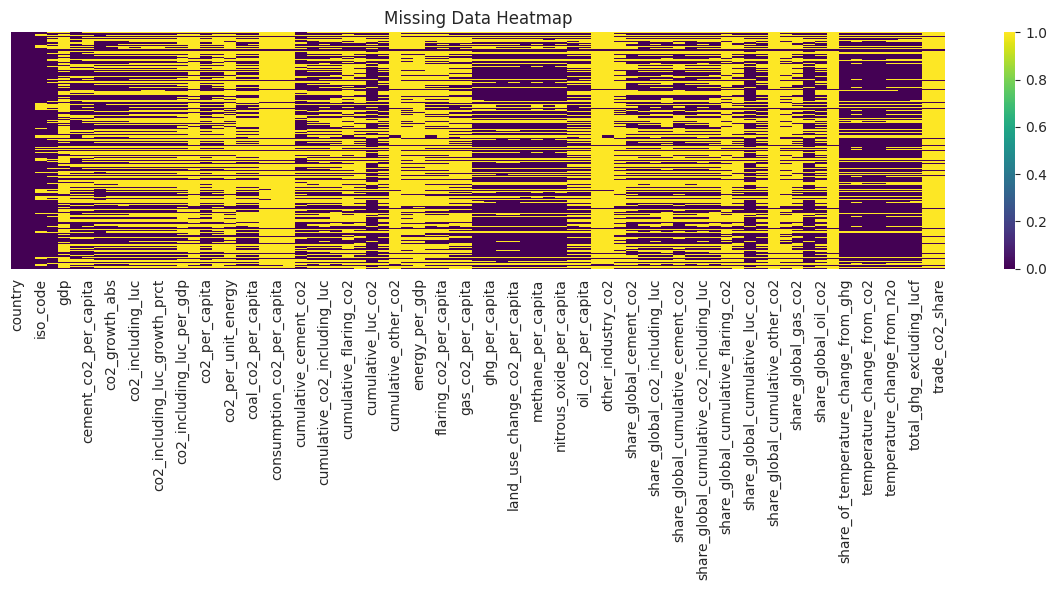

In [31]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])
print('Percent of Total Data Missing: ', round(sum(missing_pct[missing_pct > 0])/77*100, 2), '%')

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** I believe the data is MAR. It seems that there is a lot of missing data and it may be hard to bridge the gap between what is avaiable and what I need. I think for now I will drop countries that have large amounts of missing data, fill blanks with averages between the years available, and flag them as filled. It may be helpful to find another data source that could fill in the gaps.
(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)

### 2.4 Distribution Plots

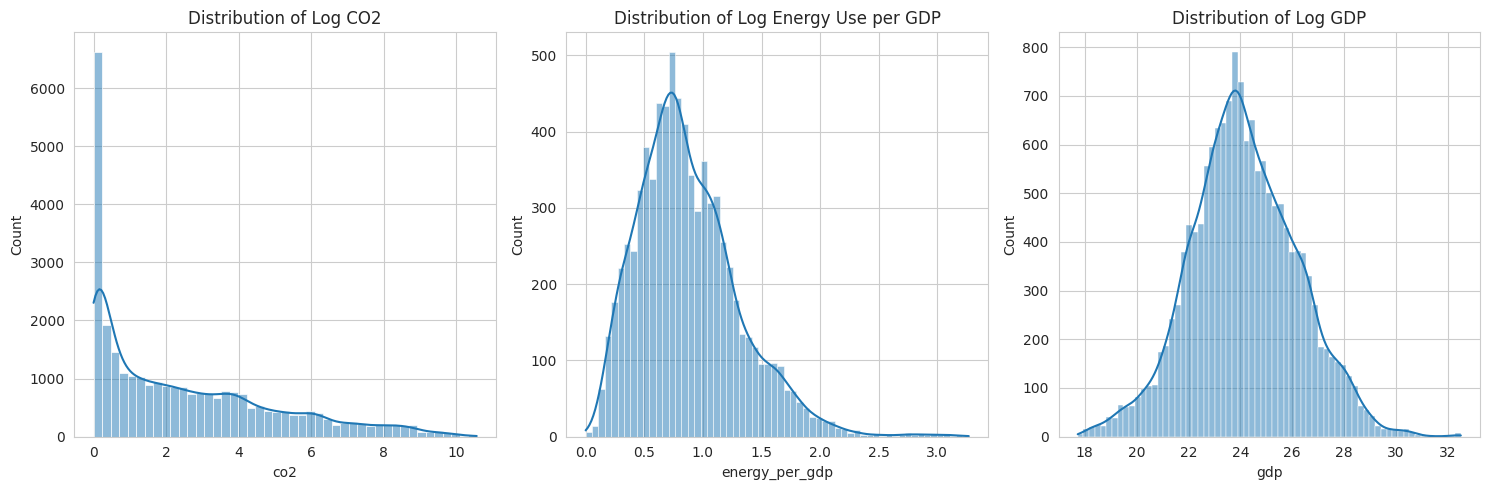

In [32]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

 # log transformed variables due to non-fitting
sns.histplot(np.log1p(df['co2']), kde=True, ax=axes[0])
axes[0].set_title('Distribution of Log CO2')

sns.histplot(np.log1p(df['energy_per_gdp']), kde=True, ax=axes[1])
axes[1].set_title('Distribution of Log Energy Use per GDP')

sns.histplot(np.log1p(df['gdp']), kde=True, ax=axes[2])
axes[2].set_title('Distribution of Log GDP')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [14]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

# Example: check outliers in a numeric column
col = 'co2'
lower, upper = tukey_fences(df[col])
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

co2: 5229 outliers (10.4%)


**Outlier strategy:** I believe that we should keep the outliers. Although there are some outliers with countries that have co2 data, it likely that those are countries with high emission rates or at a time when emissions were higher. These number are important as the outliers would line up with periods higher economic growth (in theory). The other option would economies that have extremely low or no listed emission rate. This could be structural missing data. Low-income countries will likely not collect or report data like this.
(Trim? Winsorize? Keep with justification?)

### 2.6 Correlations

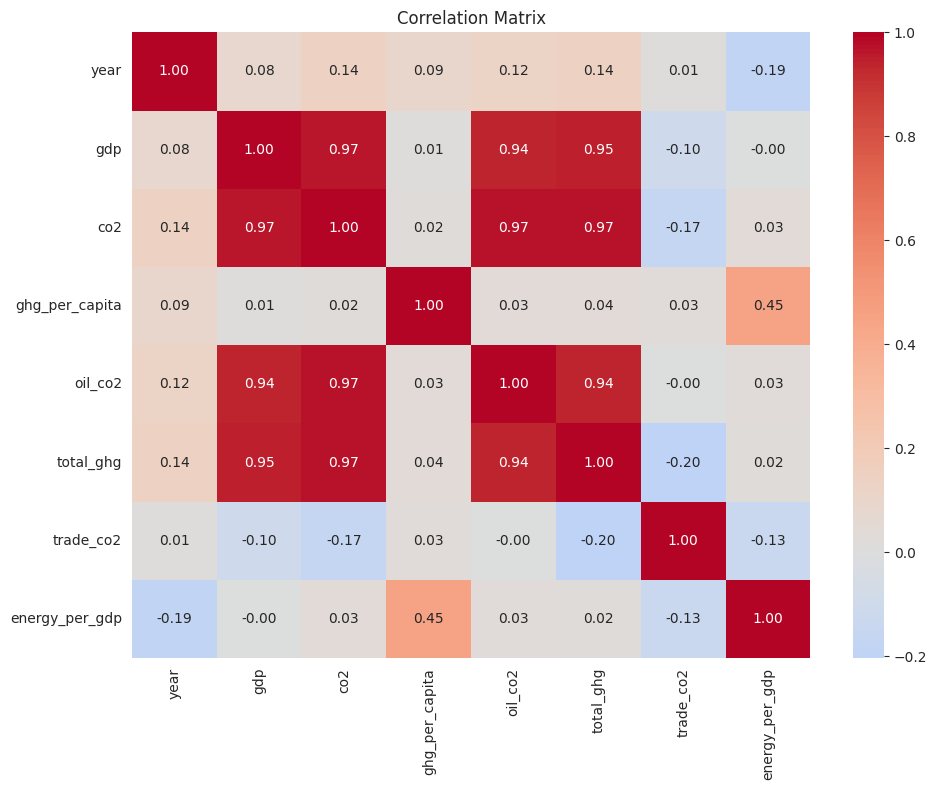

In [33]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

df_corr = df[['year', 'gdp', 'co2', 'ghg_per_capita', 'oil_co2', 'total_ghg', 'trade_co2', 'energy_per_gdp']]

numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable has a low peak at zero with a long right skew. This may be due to the large amounts of missing data at the low end of the emission report, or because the developed and industrialized countries, which account for a large majority of total emissions, drag up the distribution.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* I only chose to test correlation with a small selection of variables which I felt would tell the best story and come closer the answering the question I am asking. GDP shows strong correlation with many emissions features including CO2, Oil CO2, and Total GHG (green house gas). I would be excited to select other feature to test with. After some further data searching and cleaning, it may be better to find a more comprehesive feature list.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest issue is the missing data. After cutting out variable with a significant amount of missing data (thresh=<50%), I plan to fill in the missing data with average of the two neighboring values. This may not be a great solution, but I am also searching for more comprehensive datasets that will have less missing values.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 50411** observations and **M = 77** features.

**Missing data:** 54.25% of cells are missing. The missingness pattern appears to be [MAR] because non high-income (and high emission) countries will be more consistent about measuring this variables. I will handle missing data by cutting out largely missing features, and filling in gaps. It may also be helpful to focus on select countries that have more compelte data, but this may skew my results to be high-income country bias. Although, this bias may not matter given high-income countries are the large majority of emission either way.

**Outliers:** I identified 5229 outliers using [Tukey Fences]. I will handle them by figuring out if they are high-emission countries or missing data. I believe all data that is filled should be used since it is valuable and does not lose relavancy.

**Target variable:** The log distribution of GDP look normally distributed with a peak in the center.

**Key finding from EDA:** I think the biggest findings were the data issues that need to be patched, and the extremely strong correlation between GDP and emissions. This tells a good story and fits my original thoughts.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [39]:
 # This is the temporary solution while I look for alternative sources or find variables that are complete,
df = df.sort_values(['country', 'year'])

cols_to_interpolate = ['gdp', 'co2', 'total_ghg', 'trade_co2']

for col in cols_to_interpolate:
    df[col] = df.groupby('country')[col].transform(lambda x: x.interpolate()).ffill().bfill()

df[cols_to_interpolate]

missing_pct_int = df[cols_to_interpolate].isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct_int)

Missing data (%) by column:
gdp          0.0
co2          0.0
total_ghg    0.0
trade_co2    0.0
dtype: float64


In [41]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# df_corr = df[['year', 'gdp', 'co2', 'ghg_per_capita', 'oil_co2', 'total_ghg', 'trade_co2']]

# Define features and target
X = df[['co2', 'total_ghg', 'trade_co2']]  # Replace with your features
y = df['gdp']  # Replace with your target

# For classification: use stratify=y
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
# )

# For regression: remove stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 40328 samples
Test:  10083 samples


### 3.2 Model 1: Baseline

In [43]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
# Choose a simple, interpretable baseline:
#   Classification: LogisticRegression
  # Regression: LinearRegression or Ridge

from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

# # Classification metrics
# print('Model 1: Logistic Regression')
# print(classification_report(y_test, y_pred_1))

# Regression metrics (use these instead if regression)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

RMSE: 4354375360179.4717
MAE:  1136596174017.9326
R2:   0.5366


### 3.3 Model 2: Your Choice

In [18]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
#   Classification: RandomForestClassifier, GradientBoostingClassifier
#   Regression: RandomForestRegressor, GradientBoostingRegressor

# from sklearn.ensemble import RandomForestClassifier  # or RandomForestRegressor
#
# model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
# model_2.fit(X_train, y_train)
#
# y_pred_2 = model_2.predict(X_test)
#
# print('Model 2: Random Forest')
# print(classification_report(y_test, y_pred_2))

### 3.4 Cross-Validation Comparison

In [19]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# # Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# #                  'neg_mean_squared_error', 'r2' (regression)
# scoring = 'accuracy'
#
# cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
# cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
#
# print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
# print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
#
# # Comparison table
# comparison = pd.DataFrame({
#     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
#     f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
#     f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
# })
# comparison

---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [20]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
#
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
#
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
#
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [21]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___